<a href="https://colab.research.google.com/github/siddharthsinh-dev/iu-case-study-ml-unsupervised-learning-feature-engineering-task1/blob/main/iu_task1_ml_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Mental Health in Technology-related Jobs
### Course: Machine Learning - Unsupervised Learning and Feature Engineering (Case Study)

This notebook presents the full implementation for Task 1. A mental health survey is conducted among technology-oriented employees is analysed using unsupervised machine learning techniques. The dataset is high-dimensional and contains missing values and non-standardised inputs, which makes preprocessing important for this work.

The objective is to preprocess data, reduce its dimensionality, and apply clustering algorithms to categorise survey participants into meaningful groups.

**Dataset:** OSMI Health in Tech Survey 2016  
**Source:** https://www.kaggle.com/datasets/osmi/mental-health-in-tech-2016



**Add Kaggle API Key in Secrets in Google Colab.  
Store API Key as KAGGLE_API_TOKEN**

In [1]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# download and unzip dataset
!kaggle datasets download -d osmi/mental-health-in-tech-2016 --unzip -p /content/data/

# check downloaded files
for f in os.listdir('/content/data/'):
    print(f)

Dataset URL: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-2016
License(s): CC-BY-SA-4.0
100% 13.7M/13.7M [00:00<00:00, 87.5MB/s]

osmi-survey-2016_1479139902.json
mental-heath-in-tech-2016_20161114.csv
mental-health-in-tech-2016-neo4j-20161114


## 1. Import required libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, LocallyLinearEmbedding
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Data and View Details

In [3]:
df = pd.read_csv('/content/data/mental-heath-in-tech-2016_20161114.csv')

print("Shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(col)

Shape: (1433, 63)

Column names:
Are you self-employed?
How many employees does your company or organization have?
Is your employer primarily a tech company/organization?
Is your primary role within your company related to tech/IT?
Does your employer provide mental health benefits as part of healthcare coverage?
Do you know the options for mental health care available under your employer-provided coverage?
Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
Does your employer offer resources to learn more about mental health concerns and options for seeking help?
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
Do you think that discussing a mental health disorder with your employer would have negative con

## 3. Exploratory Data Analysis (EDA)
Before preprocessing, view and analyse data to understand its structure and data types.

In [4]:
print("Data types:\n")
print(df.dtypes)
print("\nNumber of columns by type:")
print(df.dtypes.value_counts())

Data types:

Are you self-employed?                                                                 int64
How many employees does your company or organization have?                            object
Is your employer primarily a tech company/organization?                              float64
Is your primary role within your company related to tech/IT?                         float64
Does your employer provide mental health benefits as part of healthcare coverage?     object
                                                                                      ...   
What US state or territory do you live in?                                            object
What country do you work in?                                                          object
What US state or territory do you work in?                                            object
Which of the following best describes your work position?                             object
Do you work remotely?                                    

In [5]:
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


In [6]:
df.describe(include='all')

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
count,1433.000000,1146,1146.000000,263.000000,1146,1013,1146,1146,1146,1146,...,1433,1433,1433.000000,1430,1433,840,1433,851,1433,1433
unique,NaN,6,NaN,NaN,4,3,3,3,3,6,...,5,5,NaN,70,53,47,53,48,264,3
top,NaN,26-100,NaN,NaN,Yes,No,No,No,I don't know,Somewhat easy,...,Not applicable to me,Often,NaN,Male,United States of America,California,United States of America,California,Back-end Developer,Sometimes
freq,NaN,292,NaN,NaN,531,354,813,531,742,281,...,557,538,NaN,610,840,130,851,141,263,757
mean,0.200279,NaN,0.770506,0.942966,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,34.286113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.400349,NaN,0.420691,0.232350,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.290931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)
print(f"\nTotal columns with missing values: {len(missing_df)}")

                                                    Missing Count  Missing %
If you have revealed a mental health issue to a...           1289      89.95
If yes, what percentage of your work time (time...           1229      85.76
Is your primary role within your company relate...           1170      81.65
Do you know local or online resources to seek h...           1146      79.97
If you have been diagnosed or treated for a men...           1146      79.97
If you have revealed a mental health issue to a...           1146      79.97
Do you believe your productivity is ever affect...           1146      79.97
If you have been diagnosed or treated for a men...           1146      79.97
Do you have medical coverage (private insurance...           1146      79.97
If maybe, what condition(s) do you believe you ...           1111      77.53
If yes, what condition(s) have you been diagnos...            865      60.36
Have your observations of how another individua...            776      54.15

## 4. Visualising Data Distribution

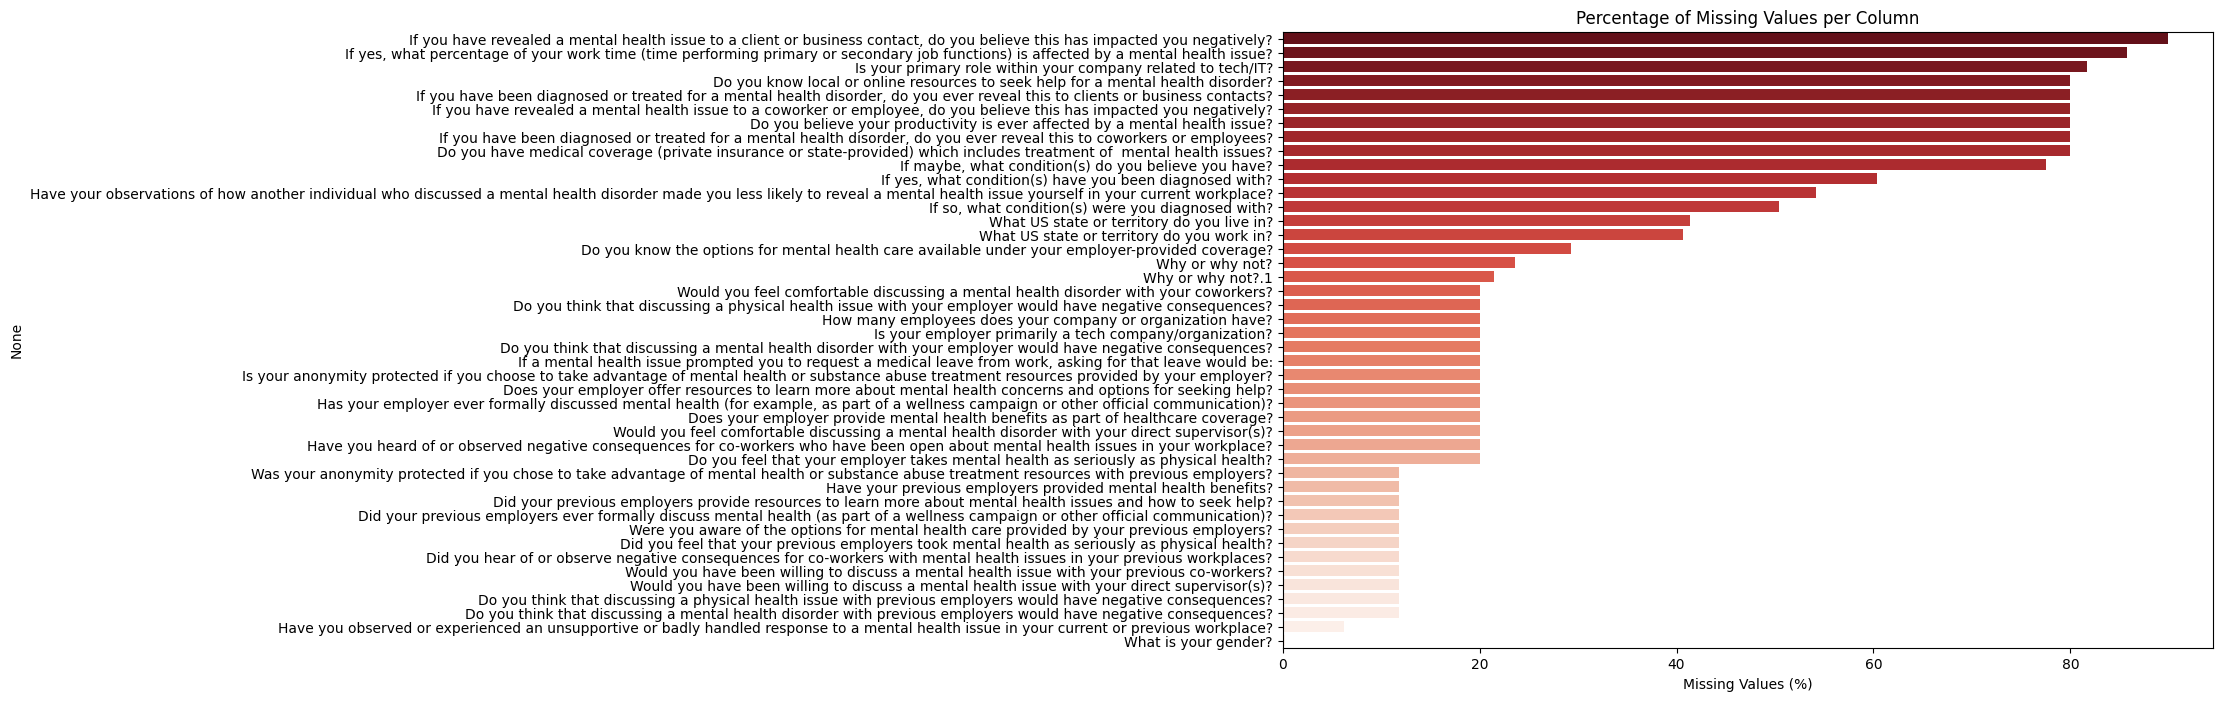

In [8]:
plt.figure(figsize=(12, 8))
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')
plt.xlabel('Missing Values (%)')
plt.title('Percentage of Missing Values per Column')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

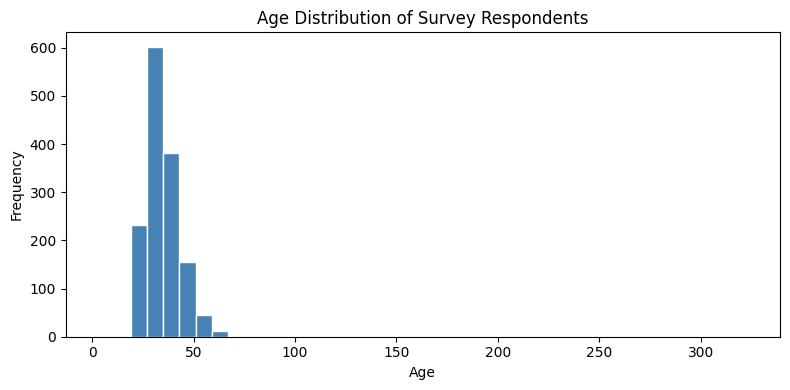

Age stats:
count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: What is your age?, dtype: float64


In [9]:
plt.figure(figsize=(8, 4))
df['What is your age?'].plot(kind='hist', bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.title('Age Distribution of Survey Respondents')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Age stats:")
print(df['What is your age?'].describe())

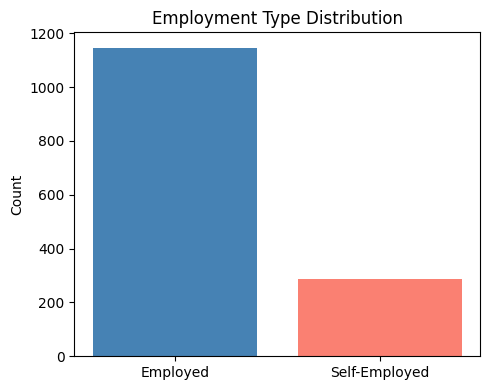

Are you self-employed?
0    1146
1     287
Name: count, dtype: int64


In [10]:
labels = ['Employed', 'Self-Employed']
counts = df['Are you self-employed?'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(labels, [counts[0], counts[1]], color=['steelblue', 'salmon'])
plt.title('Employment Type Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('employment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(counts)

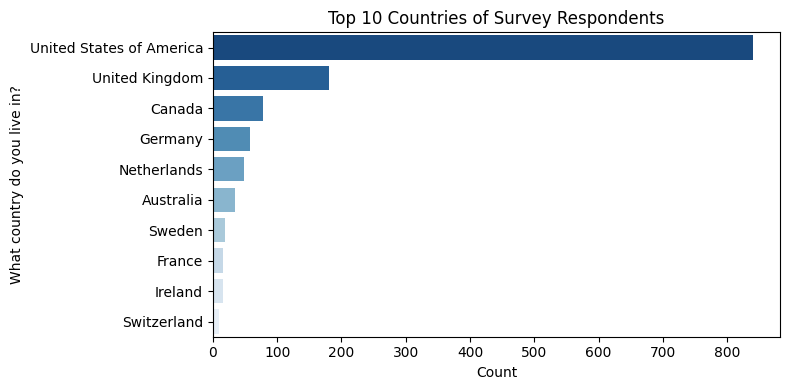

In [11]:
top_countries = df['What country do you live in?'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.xlabel('Count')
plt.title('Top 10 Countries of Survey Respondents')
plt.tight_layout()
plt.savefig('country_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing and Cleaning

Exploratory data analysis reveals three patterns of missingness and data quality issues that need resolving before any machine learning can be applied. The cleaning strategy is designed around these patterns rather than applying a uniform approach across all columns.

The 287 respondents who are self-employed account for 20% missingness across all-employer related columns, since those questions are not applicable to them. Similarly, the 169 respondents without previous employers explain the 11.79% missingness in previous employer columns. These are **Missing Not At Random (MNAR)**. Dropping these rows would introduce bias, so missing values in the columns are filled with a sentinel value indicating non-applicability rather than unknown.

In [12]:
# drop columns with over 79% missing
missing_pct = (df.isnull().sum() / len(df)) * 100
high_missing_cols = missing_pct[missing_pct > 79].index.tolist()

# free text columns - not usable for clustering
free_text = [col for col in df.columns if 'Why or why not' in col]

# US state columns
state_cols = [col for col in df.columns if 'US state' in col]

cols_to_drop = list(set(high_missing_cols + free_text + state_cols))
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns dropped: {len(cols_to_drop)}")
print(f"Remaining columns: {df.shape[1]}")
print("\nDropped columns:")
for col in cols_to_drop:
    print(col)

Columns dropped: 13
Remaining columns: 50

Dropped columns:
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?
Why or why not?
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?
Why or why not?.1
If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?
Is your primary role within your company related to tech/IT?
If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?
Do you believe your productivity is ever affected by a mental health issue?
What US state or territory do you live in?
What US state or territory do you work in?
Do you know local or online resources to seek help for a mental healt

In [13]:
# fill missing employer columns with Not Applicable (self-employed respondents)
employer_keyword = [
    'employees does your company',
    'employer primarily a tech',
    'employer provide mental health benefits',
    'options for mental health care available under your employer',
    'employer ever formally discussed',
    'employer offer resources',
    'anonymity protected if you choose',
    'medical leave from work',
    'discussing a mental health disorder with your employer',
    'discussing a physical health issue with your employer',
    'comfortable discussing a mental health disorder with your coworkers',
    'comfortable discussing a mental health disorder with your direct supervisor',
    'employer takes mental health',
    'negative consequences for co-workers who have been open'
]

# fill missing previous employer columns with Not Applicable
prev_employer_keywords = [
    'previous employers provided mental health',
    'options for mental health care provided by your previous',
    'previous employers ever formally discuss',
    'previous employers provide resources',
    'anonymity protected if you chose',
    'discussing a mental health disorder with previous employers',
    'discussing a physical health issue with previous employers',
    'willing to discuss a mental health issue with your previous co-workers',
    'willing to discuss a mental health issue with your direct supervisor',
    'previous employers took mental health',
    'negative consequences for co-workers with mental health issues in your previous'
]

def fill_mnar(df, keywords, fill_value='Not Applicable', numeric_fill=-1):
    for keyword in keywords:
        matched = [col for col in df.columns if keyword.lower() in col.lower()]
        for col in matched:
            if df[col].dtype == object:
                df[col].fillna(fill_value, inplace=True)
            else:
                df[col].fillna(numeric_fill, inplace=True)

fill_mnar(df, employer_keyword)
fill_mnar(df, prev_employer_keywords)

print("MNAR missing values handled.")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

MNAR missing values handled.
Remaining missing values: 3566


## Column Specific Data Cleaning

In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

If maybe, what condition(s) do you believe you have?                                                                                                                                1111
If yes, what condition(s) have you been diagnosed with?                                                                                                                              865
Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?     776
If so, what condition(s) were you diagnosed with?                                                                                                                                    722
Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?                                            89
What is your gender?                                                       

In [15]:
obs_col = [col for col in df.columns if 'how another individual' in col.lower()]
df.drop(columns=obs_col, inplace=True)
print("Dropped:", obs_col)

Dropped: ['Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?']


In [16]:
df['What is your gender?'].fillna('Undisclosed', inplace=True)
print("Gender missing values:", df['What is your gender?'].isnull().sum())

Gender missing values: 0


In [17]:
col = [c for c in df.columns if 'unsupportive or badly handled' in c.lower()][0]
most_frequent = df[col].mode()[0]
df[col].fillna(most_frequent, inplace=True)
print(f"Filled '{col}' with: {most_frequent}")

Filled 'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?' with: No


In [18]:
# combine three diagnosis columns into one
col_yes = [c for c in df.columns if 'what condition(s) have you been diagnosed with' in c.lower()][0]
col_maybe = [c for c in df.columns if 'what condition(s) do you believe you have' in c.lower()][0]
col_prof = [c for c in df.columns if 'what condition(s) were you diagnosed with' in c.lower()][0]

def combine_diagnosis(row):
    for col in [col_prof, col_yes, col_maybe]:
        if pd.notna(row[col]) and str(row[col]).strip() != '':
            return row[col]
    return 'No Diagnosis'

df['combined_diagnosis'] = df.apply(combine_diagnosis, axis=1)

# drop the three original columns
df.drop(columns=[col_yes, col_maybe, col_prof], inplace=True)

print("Combined diagnosis column created.")
print(f"Remaining columns: {df.shape[1]}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("\nSample values:")
print(df['combined_diagnosis'].value_counts().head(10))

Combined diagnosis column created.
Remaining columns: 47
Remaining missing values: 0

Sample values:
combined_diagnosis
No Diagnosis                                                                                                                                      460
Mood Disorder (Depression, Bipolar Disorder, etc)                                                                                                 227
Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)                                             183
Anxiety Disorder (Generalized, Social, Phobia, etc)                                                                                                93
Anxiety Disorder (Generalized, Social, Phobia, etc)|Mood Disorder (Depression, Bipolar Disorder, etc)|Attention Deficit Hyperactivity Disorder     39
Attention Deficit Hyperactivity Disorder                                                                                          

## 6. Feature Engineering
Now, as the missing values are resolved, shift focus to transforming raw column values into a form usable by machine learning algorithms. Several columns contain non-standardised free-text inputs, multi-label entries, or inconsistent categories that need to be consolidated before encoding.

In [19]:
def standardise_gender(val):
    val = str(val).strip().lower()
    if any(x in val for x in ['female', 'woman', 'f', 'cis f', 'cisgender female']):
        return 'Female'
    elif any(x in val for x in ['male', 'man', 'm', 'cis m', 'cisgender male']):
        return 'Male'
    elif val == 'undisclosed':
        return 'Undisclosed'
    else:
        return 'Non-binary/Other'

df['gender_clean'] = df['What is your gender?'].apply(standardise_gender)
print(df['gender_clean'].value_counts())

gender_clean
Male                1058
Female               354
Non-binary/Other      18
Undisclosed            3
Name: count, dtype: int64


In [20]:
# remove unrealistic age values
df = df[(df['What is your age?'] >= 18) & (df['What is your age?'] <= 75)]
df.rename(columns={'What is your age?': 'age'}, inplace=True)

print(f"Rows after age cleaning: {len(df)}")
print(df['age'].describe())

Rows after age cleaning: 1428
count    1428.000000
mean       34.086134
std         8.086273
min        19.000000
25%        28.000000
50%        33.000000
75%        39.000000
max        74.000000
Name: age, dtype: float64


In [21]:
def simplify_diagnosis(val):
    val = str(val)
    if val == 'No Diagnosis':
        return 'No Diagnosis'
    elif 'Mood Disorder' in val and 'Anxiety' in val:
        return 'Anxiety and Mood Disorder'
    elif 'Mood Disorder' in val:
        return 'Mood Disorder'
    elif 'Anxiety Disorder' in val:
        return 'Anxiety Disorder'
    elif 'Attention Deficit' in val:
        return 'ADHD'
    elif 'Post-traumatic' in val:
        return 'PTSD'
    elif 'Substance' in val:
        return 'Substance Use Disorder'
    else:
        return 'Other'

df['diagnosis_clean'] = df['combined_diagnosis'].apply(simplify_diagnosis)
print(df['diagnosis_clean'].value_counts())

diagnosis_clean
No Diagnosis                 457
Anxiety and Mood Disorder    363
Mood Disorder                330
Anxiety Disorder             161
Other                         54
ADHD                          39
PTSD                          13
Substance Use Disorder        11
Name: count, dtype: int64


In [22]:
# work position has pipe-separated multi-role values
# extract the first listed role as primary role
def primary_role(val):
    val = str(val).strip()
    first = val.split('|')[0].strip()
    common_roles = [
        'Back-end Developer', 'Front-end Developer', 'Full-stack Developer',
        'DevOps/SysAdmin', 'Data Scientist', 'Designer', 'Support',
        'Executive Leadership', 'Supervisor/Team Lead', 'One-person shop'
    ]
    for role in common_roles:
        if role.lower() in first.lower():
            return role
    return 'Other'

df['work_position_clean'] = df['Which of the following best describes your work position?'].apply(primary_role)
print(df['work_position_clean'].value_counts())

work_position_clean
Back-end Developer      369
Front-end Developer     234
Other                   227
Supervisor/Team Lead    178
DevOps/SysAdmin         137
One-person shop         104
Executive Leadership     71
Support                  63
Designer                 45
Name: count, dtype: int64


In [23]:
def simplify_country(val):
    if val == 'United States of America':
        return 'USA'
    elif val == 'United Kingdom':
        return 'UK'
    elif val == 'Canada':
        return 'Canada'
    elif val == 'Germany':
        return 'Germany'
    else:
        return 'Other'

df['country_clean'] = df['What country do you live in?'].apply(simplify_country)
print(df['country_clean'].value_counts())

country_clean
USA        838
Other      276
UK         180
Canada      76
Germany     58
Name: count, dtype: int64


In [24]:
cols_to_drop = [
    'What is your gender?',
    'Which of the following best describes your work position?',
    'What country do you live in?',
    'What country do you work in?',
    'combined_diagnosis'
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns: {df.shape[1]}")
print(f"Remaining rows: {df.shape[0]}")

Remaining columns: 46
Remaining rows: 1428


In [25]:
for col in df.columns:
    print(col)

Are you self-employed?
How many employees does your company or organization have?
Is your employer primarily a tech company/organization?
Does your employer provide mental health benefits as part of healthcare coverage?
Do you know the options for mental health care available under your employer-provided coverage?
Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
Does your employer offer resources to learn more about mental health concerns and options for seeking help?
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
Do you think that discussing a mental health disorder with your employer would have negative consequences?
Do you think that discussing a physical health issue with your employer would have 

## Feature Encoding

Machine learning algorithms require numerical input. The remaining categorical columns are encoded using two approaches depending on their scale type.

Ordinal columns, where categories have natural order, are mapped to integers that preserve that order.  
Nominal columns, where no natural order exists, are one-hot encoded to avoid implying any hierarchy between categories.

**Ordinal Encoding**

In [26]:
ordinal_mappings = {
    'How many employees does your company or organization have?': {
        'Not Applicable': 0, '1-5': 1, '6-25': 2, '26-100': 3,
        '100-500': 4, '500-1000': 5, 'More than 1000': 6
    },
    'Do you work remotely?': {
        'Never': 0, 'Sometimes': 1, 'Always': 2
    },
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': {
        'Not Applicable': 0, 'Very difficult': 1, 'Somewhat difficult': 2,
        'Neither easy nor difficult': 3, 'Somewhat easy': 4, 'Very easy': 5
    },
    'How willing would you be to share with friends and family that you have a mental illness?': {
        'Not open at all': 1, 'Somewhat not open': 2, 'Neutral': 3,
        'Somewhat open': 4, 'Very open': 5
    },
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': {
        'Not applicable to me': 0, 'Never': 1, 'Rarely': 2,
        'Sometimes': 3, 'Often': 4
    },
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': {
        'Not applicable to me': 0, 'Never': 1, 'Rarely': 2,
        'Sometimes': 3, 'Often': 4
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        unmapped = df[col].isnull().sum()
        if unmapped > 0:
            print(f"Warning: {unmapped} unmapped values in '{col}'")

print("Ordinal encoding done.")
print(f"Missing values after ordinal encoding: {df.isnull().sum().sum()}")

Ordinal encoding done.
Missing values after ordinal encoding: 260


**First, checking Unmapped values**

In [27]:
col1 = 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:'
col2 = 'How willing would you be to share with friends and family that you have a mental illness?'

print("Medical leave column unique values:")
print(df[col1].unique())

print("\nFamily sharing column unique values:")
print(df[col2].unique())

Medical leave column unique values:
[ 5.  4.  3.  0.  1.  2. nan]

Family sharing column unique values:
[ 4.  3. nan  5.  1.  2.]


**NaN values are unmapped. Fill them with 0**

In [28]:
col1 = 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:'
col2 = 'How willing would you be to share with friends and family that you have a mental illness?'

df[col1].fillna(0, inplace=True)
df[col2].fillna(0, inplace=True)

print(f"Missing values after fix: {df.isnull().sum().sum()}")

Missing values after fix: 0


**Binary encoding for Yes/No columns**

In [29]:
# map common yes/no/not applicable responses to numbers
binary_mapping = {
    'Yes': 1, 'No': 0, 'Not Applicable': -1,
    'Maybe': 0.5, "I don't know": -0.5,
    'Some of them': 0.5, 'None of them': 0,
    'N/A': -1
}

binary_cols = [
    'Is your employer primarily a tech company/organization?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
    'Do you feel that your employer takes mental health as seriously as physical health?',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?',
    'Do you have previous employers?',
    'Have your previous employers provided mental health benefits?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?',
    'Did you feel that your previous employers took mental health as seriously as physical health?',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?',
    'Would you bring up a mental health issue with a potential employer in an interview?',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'Do you have a family history of mental illness?',
    'Have you had a mental health disorder in the past?',
    'Do you currently have a mental health disorder?',
    'Have you been diagnosed with a mental health condition by a medical professional?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?'
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

print(f"Missing values after binary encoding: {df.isnull().sum().sum()}")
print(f"Unmapped check:")
for col in binary_cols:
    if col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            print(f"  {n} unmapped in: {col}")

Missing values after binary encoding: 15806
Unmapped check:
  1428 unmapped in: Is your employer primarily a tech company/organization?
  83 unmapped in: Does your employer provide mental health benefits as part of healthcare coverage?
  351 unmapped in: Do you know the options for mental health care available under your employer-provided coverage?
  1428 unmapped in: Do you have previous employers?
  947 unmapped in: Have your previous employers provided mental health benefits?
  1260 unmapped in: Were you aware of the options for mental health care provided by your previous employers?
  1174 unmapped in: Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?
  1260 unmapped in: Did your previous employers provide resources to learn more about mental health issues and how to seek help?
  283 unmapped in: Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment re

**Many Unmapped Values still remain**

In [30]:
problem_cols = [
    'Is your employer primarily a tech company/organization?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Do you have previous employers?',
    'Have your previous employers provided mental health benefits?',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?'
]

for col in problem_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].unique())


Is your employer primarily a tech company/organization?:
[nan]

Does your employer provide mental health benefits as part of healthcare coverage?:
[ nan  0.  -1.   1.  -0.5]

Do you know the options for mental health care available under your employer-provided coverage?:
[-1.  1. nan  0.]

Do you have previous employers?:
[nan]

Have your previous employers provided mental health benefits?:
[ nan -0.5 -1. ]

Do you feel that being identified as a person with a mental health issue would hurt your career?:
[0.5 nan]

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?:
[nan 0.5]

Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?:
[ 0. nan]

Have you ever sought treatment for a mental health issue from a mental health professional?:
[nan]


**Fill all remaining NaN with -1**

In [31]:
df.fillna(-1, inplace=True)

print(f"Missing values after final fill: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Missing values after final fill: 0
Dataset shape: (1428, 46)


In [32]:
nominal_cols = ['gender_clean', 'diagnosis_clean', 'work_position_clean', 'country_clean']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

print(f"Shape after one-hot encoding: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape after one-hot encoding: (1428, 68)
Missing values: 0


In [33]:
print(f"Final dataset shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nAny missing values: {df.isnull().any().any()}")

Final dataset shape: (1428, 68)

Data types:
float64    36
bool       26
int64       6
Name: count, dtype: int64

Any missing values: False


**Data Preprocessing and Feature Engineering**  
Columns with over 79% missing data were dropped since imputation at that scale is unreliable. Employer-related columns missing due to self-employment were filled with sentinel values rather than dropped because these are cases of **Missing Not At Random (MNAR)**, where the absence of a response carries a meaning in itself.

The three diagnosis columns were merged into one to reduce redundancy. Gender and work position needed consolidation because free text inputs produced 70 and 264 unique values, most of which were variations of the same category. Ordinal columns were integer-encoded to preserve order and nominal columns were one-hot encoded. The final dataset has 1428 rows and 68 features with no missing values.

One limitation is that the sentinel value of -1 for non-applicable responses may affect distance calculation in clustering during evaluation.

## 7. Data Standardisation
Before applying dimensionality reduction and clustering, data is standardised using StandardScaler. K-means and other distance-based algorithms are sensitive to the scale of features - a feature with a large numeric range would otherwise dominate the distance calculations over features with smaller ranges.

Standardisation transforms each feature to have a mean of 0 and a standard deviation of 1, ensuring all features contribute equally to the analysis.

In [34]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# keep as dataframe with column names
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print(f"Shape after standardisation: {df_scaled.shape}")
print(f"\nSample means (should be close to 0):")
print(df_scaled.mean().head(5).round(4))
print(f"\nSample std (should be close to 1):")
print(df_scaled.std().head(5).round(4))

Shape after standardisation: (1428, 68)

Sample means (should be close to 0):
Are you self-employed?                                                                             0.0
How many employees does your company or organization have?                                        -0.0
Is your employer primarily a tech company/organization?                                            0.0
Does your employer provide mental health benefits as part of healthcare coverage?                  0.0
Do you know the options for mental health care available under your employer-provided coverage?   -0.0
dtype: float64

Sample std (should be close to 1):
Are you self-employed?                                                                             1.0004
How many employees does your company or organization have?                                         1.0004
Is your employer primarily a tech company/organization?                                            0.0000
Does your employer provide mental heal

## 8. Feature Selection  
With 68 features, some reduction is needed before applying dimensionality reduction and clustering.   
**Two filter-based methods are applied:**    
First, zero-variance features are removed since they carry no information at all.  
Second, a correlation matrix is used to identify and remove highly correlated features, as redundant features can distort clustering by overweighting certain dimensions.

In [35]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(df_scaled)

zero_var_cols = df_scaled.columns[~selector.get_support()].tolist()
print(f"Zero variance columns removed: {len(zero_var_cols)}")
for col in zero_var_cols:
    print(col)

df_scaled = df_scaled[df_scaled.columns[selector.get_support()]]
print(f"\nShape after variance filtering: {df_scaled.shape}")

Zero variance columns removed: 6
Is your employer primarily a tech company/organization?
Do you have previous employers?
Were you aware of the options for mental health care provided by your previous employers?
Did your previous employers provide resources to learn more about mental health issues and how to seek help?
Would you have been willing to discuss a mental health issue with your previous co-workers?
Have you ever sought treatment for a mental health issue from a mental health professional?

Shape after variance filtering: (1428, 62)


In [36]:
corr_matrix = df_scaled.corr().abs()

# keep upper triangle only
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# drop features with correlation above 0.85
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Highly correlated columns removed: {len(high_corr_cols)}")
for col in high_corr_cols:
    print(col)

df_scaled = df_scaled.drop(columns=high_corr_cols)
print(f"\nShape after correlation filtering: {df_scaled.shape}")

Highly correlated columns removed: 6
Do you think that discussing a mental health disorder with your employer would have negative consequences?
Do you think that discussing a physical health issue with your employer would have negative consequences?
Would you feel comfortable discussing a mental health disorder with your coworkers?
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?
Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?
gender_clean_Male

Shape after correlation filtering: (1428, 56)


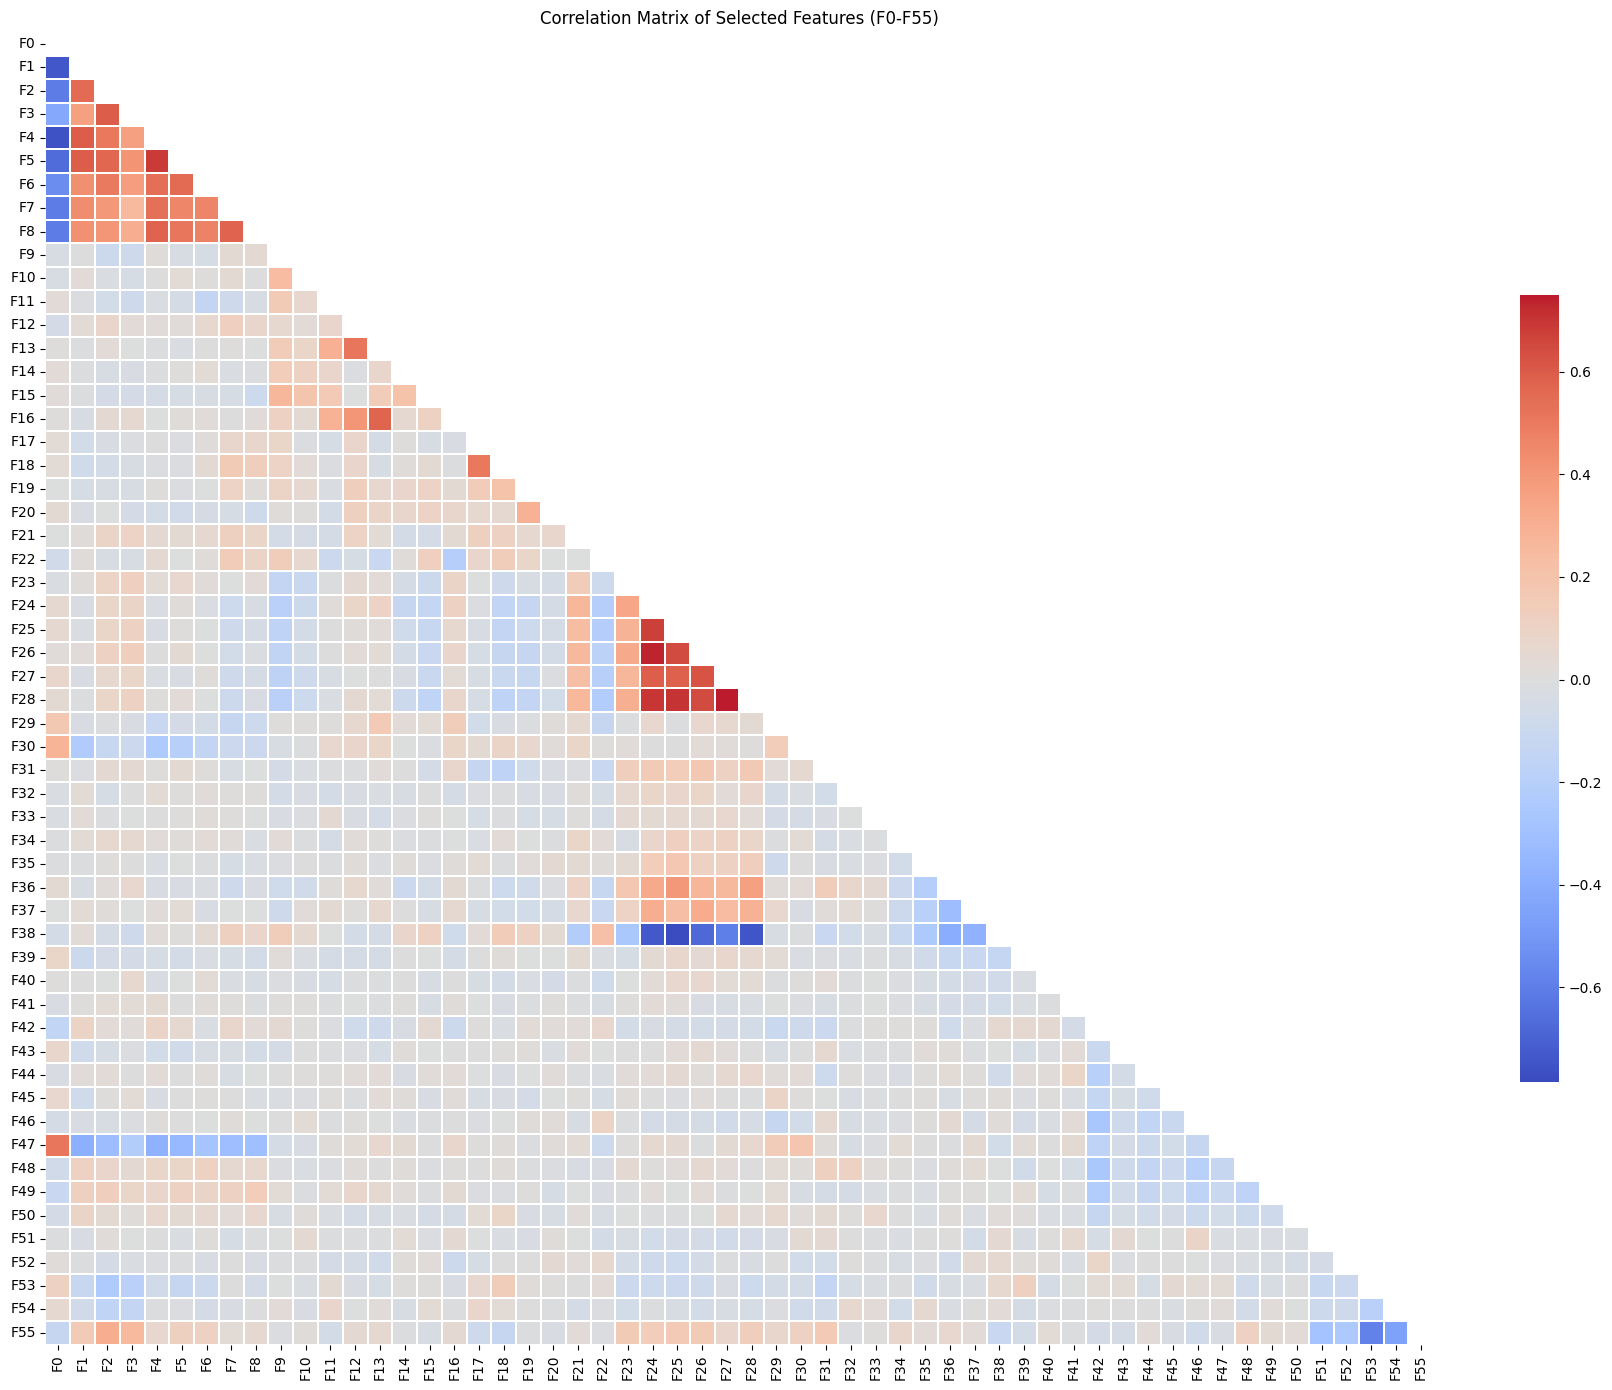

In [37]:
# create short labels for visualisation only
short_labels = [f"F{i}" for i in range(df_scaled.shape[1])]

corr_final = df_scaled.corr()
mask = np.triu(np.ones_like(corr_final, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(corr_final, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={"shrink": 0.6},
            xticklabels=short_labels, yticklabels=short_labels)
plt.title('Correlation Matrix of Selected Features (F0-F55)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# print the legend so we know which F corresponds to which feature
for i, col in enumerate(df_scaled.columns):
    print(f"F{i}: {col}")

F0: Are you self-employed?
F1: How many employees does your company or organization have?
F2: Does your employer provide mental health benefits as part of healthcare coverage?
F3: Do you know the options for mental health care available under your employer-provided coverage?
F4: Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
F5: Does your employer offer resources to learn more about mental health concerns and options for seeking help?
F6: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
F7: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
F8: Do you feel that your employer takes mental health as seriously as physical health?
F9: Have your previous employers provided mental health benefits?
F10: Did your previous employers ever formally discuss menta

During Feature Selection, 6 zero-variance features were removed. These columns had become constant after the MNAR sentinel value filling, meaning all respondents had the same value and the feature carried no useful information.   

Another 6 features were removed due to correlation above 0.85, as they were talking about the same topic from slightly different way or angle.  

The final 56 features cover employer support, previous employer experience, personal mental health history, workplace attitudes, and demographic information.  

The correlation heatmap confirms that most remaining features are reasonably independent, with the strongest correlation appearing within logically related feature groups like personal diagnosis history and work interference.

## 9. Dimensionality Reduction  

Now, the cleaned and standardised dataset contains 56 features. Applying clustering directly to high-dimensional data is ineffective because distance metrics become less meaningful as dimensionality increases, due to curse of dimensionality. Dimensionality reduction compresses the data into a lower-dimensional space while preserving its main structure.  

First, PCA is applied as the primary method. It is computationally efficient and good for datasets where linear relationships dominate. The number of components is selected based on cumulative explained variance.  

Then, MDS is applied as a comparison, as it preserves pairwise distances rather than variance and can capture non-linear structure in the data.

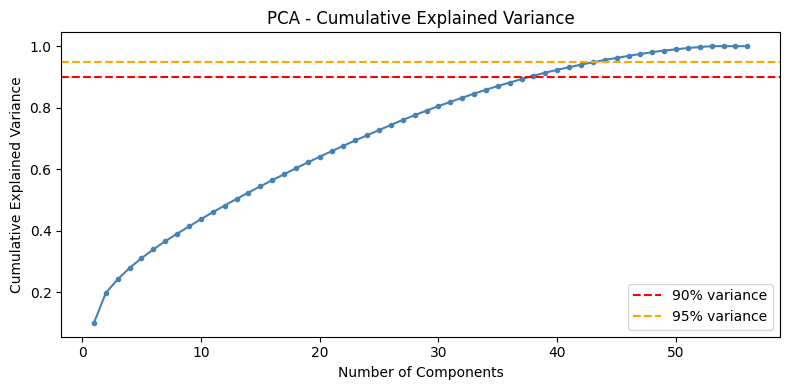

Components for 90% variance: 38
Components for 95% variance: 44


In [39]:
pca_full = PCA()
pca_full.fit(df_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# find components needed for 90% and 95%
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

In [40]:
# PCA with 38 components for clustering (90% variance retained)
pca_38 = PCA(n_components=38)
df_pca_38 = pca_38.fit_transform(df_scaled)
print(f"PCA (38 components) shape: {df_pca_38.shape}")
print(f"Variance retained: {pca_38.explained_variance_ratio_.sum():.3f}")

# PCA with 2 components for visualisation only
pca_2 = PCA(n_components=2)
df_pca_2 = pca_2.fit_transform(df_scaled)
print(f"\nPCA (2 components) shape: {df_pca_2.shape}")
print(f"Variance retained: {pca_2.explained_variance_ratio_.sum():.3f}")

PCA (38 components) shape: (1428, 38)
Variance retained: 0.904

PCA (2 components) shape: (1428, 2)
Variance retained: 0.198


In [41]:
# MDS with 2 components for visualisation and comparison
mds = MDS(n_components=2, random_state=42, max_iter=300, n_init=4)
df_mds = mds.fit_transform(df_scaled)
print(f"MDS shape: {df_mds.shape}")

MDS shape: (1428, 2)


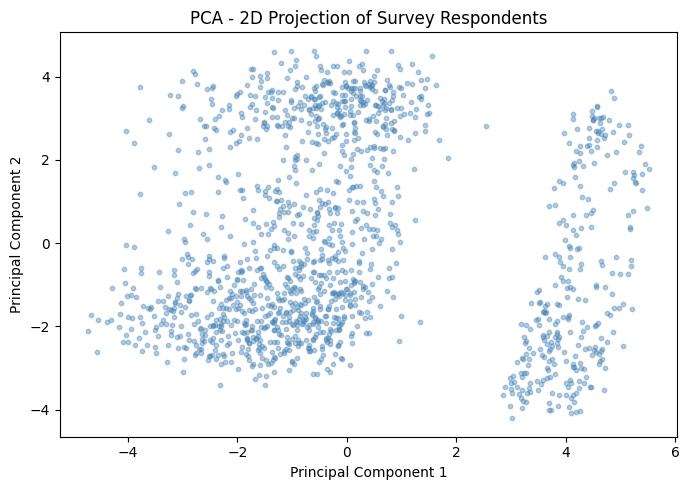

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(df_pca_2[:, 0], df_pca_2[:, 1],
            alpha=0.4, s=10, color='steelblue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Projection of Survey Respondents')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

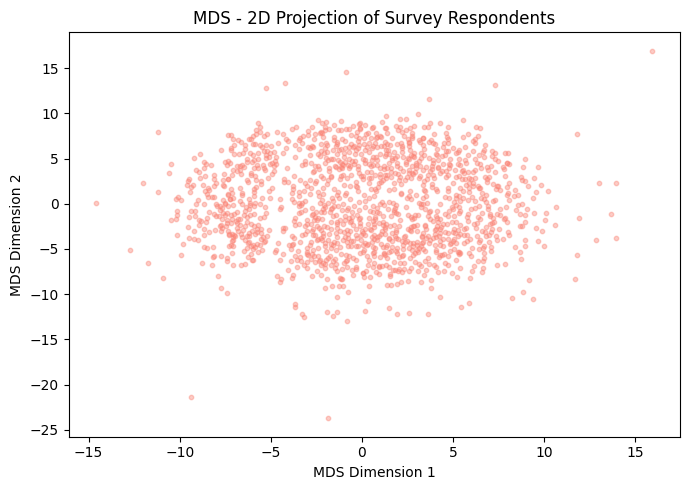

In [43]:
plt.figure(figsize=(7, 5))
plt.scatter(df_mds[:, 0], df_mds[:, 1],
            alpha=0.4, s=10, color='salmon')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS - 2D Projection of Survey Respondents')
plt.tight_layout()
plt.savefig('mds_2d.png', dpi=150, bbox_inches='tight')
plt.show()

**Dimensionality Reduction Results**  

PCA requires 38 components to retain 90% of the variance in the dataset. The gradual slope of the explained variance curve indicates that information is distributed across many features rather than being concentrated in a few directions. This is consistent with the survey data, where different question groups capture different aspects of respondent experience.

The 2D PCA projection shows a clear structural separation with a dense central group and a distinct vertical cluster on the right. This separation along with first principal components is driven by the self-employment status. Because, self-employed respondents have sentinel values across all employer-related features, placing them apart from employed respondents.  

MDS produced a single elliptical cloud shape with no visible grouping, showing that the data does not contain strong non-linear distance based structure beyond what PCA already captures.  

Hence, PCA is used as the primary dimensionality reduction method. The 38 component representation is used for clustering and the 2 component projection is used for visualisation.  

## 10. Clustering  

K-means is applied as the primary clustering algorithm. It is computationally efficient and well-suited to this dataset size. To determine the optimal number of clusters, two methods can be used:  
1. The elbow method which looks for the point where adding more clusters yields diminishing returns in inertia reduction  

2. Silhouette score, which measures how-well separated the clusters are.  

Then, apply Gaussian Mixture Models and Hierarchical clustering for comparison.

**Elbow Method**

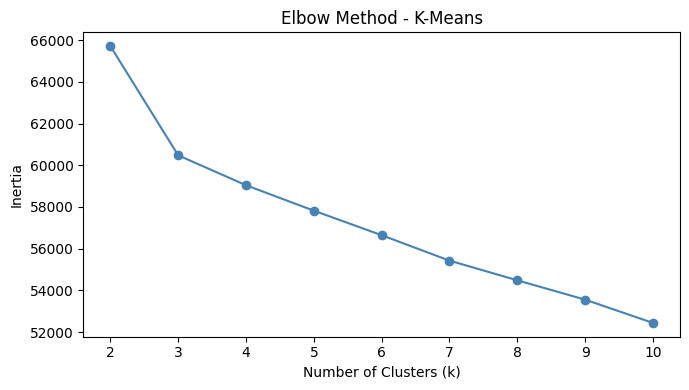

In [44]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_pca_38)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - K-Means')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

**Silhouette Scores**

k=2, silhouette score: 0.1297
k=3, silhouette score: 0.1027
k=4, silhouette score: 0.1072
k=5, silhouette score: 0.0811
k=6, silhouette score: 0.0798
k=7, silhouette score: 0.0709
k=8, silhouette score: 0.0609
k=9, silhouette score: 0.0754
k=10, silhouette score: 0.0546


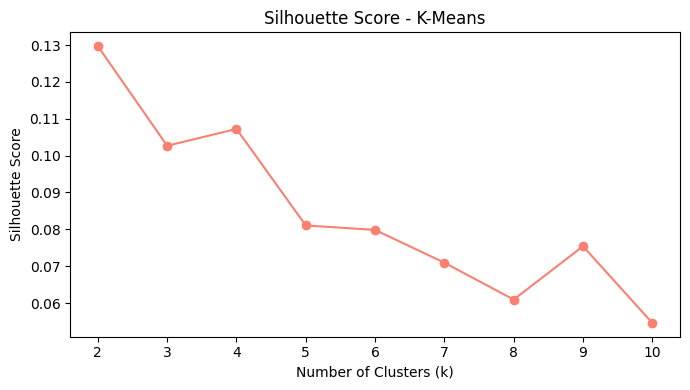

In [45]:
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca_38)
    score = silhouette_score(df_pca_38, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score: {score:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='salmon')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - K-Means')
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Use K = 3

In [46]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_final.fit_predict(df_pca_38)

print("K-Means cluster distribution:")
unique, counts = np.unique(km_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} respondents ({c/len(km_labels)*100:.1f}%)")

K-Means cluster distribution:
  Cluster 0: 683 respondents (47.8%)
  Cluster 1: 459 respondents (32.1%)
  Cluster 2: 286 respondents (20.0%)


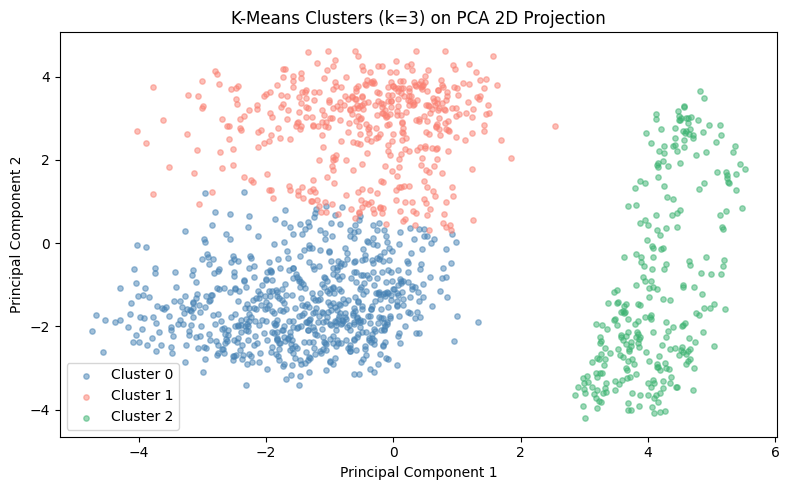

In [47]:
colors = ['steelblue', 'salmon', 'mediumseagreen']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(8, 5))
for i in range(3):
    mask = km_labels == i
    plt.scatter(df_pca_2[mask, 0], df_pca_2[mask, 1],
                c=colors[i], label=cluster_names[i],
                alpha=0.5, s=15)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (k=3) on PCA 2D Projection')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(df_pca_38)

print("GMM cluster distribution:")
unique, counts = np.unique(gmm_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} respondents ({c/len(gmm_labels)*100:.1f}%)")

gmm_silhouette = silhouette_score(df_pca_38, gmm_labels)
km_silhouette = silhouette_score(df_pca_38, km_labels)
print(f"\nK-Means silhouette score: {km_silhouette:.4f}")
print(f"GMM silhouette score: {gmm_silhouette:.4f}")

GMM cluster distribution:
  Cluster 0: 98 respondents (6.9%)
  Cluster 1: 1051 respondents (73.6%)
  Cluster 2: 279 respondents (19.5%)

K-Means silhouette score: 0.1027
GMM silhouette score: 0.1257


In [49]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(df_pca_38)

hc_silhouette = silhouette_score(df_pca_38, hc_labels)
print("Hierarchical cluster distribution:")
unique, counts = np.unique(hc_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} respondents ({c/len(hc_labels)*100:.1f}%)")

print(f"\nHierarchical silhouette score: {hc_silhouette:.4f}")

Hierarchical cluster distribution:
  Cluster 0: 651 respondents (45.6%)
  Cluster 1: 216 respondents (15.1%)
  Cluster 2: 561 respondents (39.3%)

Hierarchical silhouette score: 0.0629


**K-means is the best choice because it produces three balanced, visually well-separated groups that align with the PCA structure. Hierarchical results also confirm K-means is more stable.**

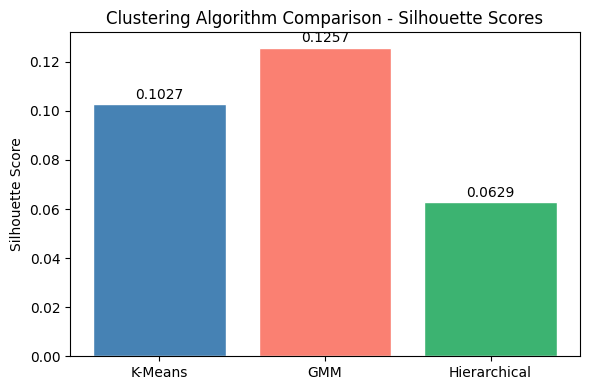

In [50]:
algorithms = ['K-Means', 'GMM', 'Hierarchical']
scores = [km_silhouette, gmm_silhouette, hc_silhouette]
colors_bar = ['steelblue', 'salmon', 'mediumseagreen']

plt.figure(figsize=(6, 4))
bars = plt.bar(algorithms, scores, color=colors_bar, edgecolor='white')
plt.ylabel('Silhouette Score')
plt.title('Clustering Algorithm Comparison - Silhouette Scores')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

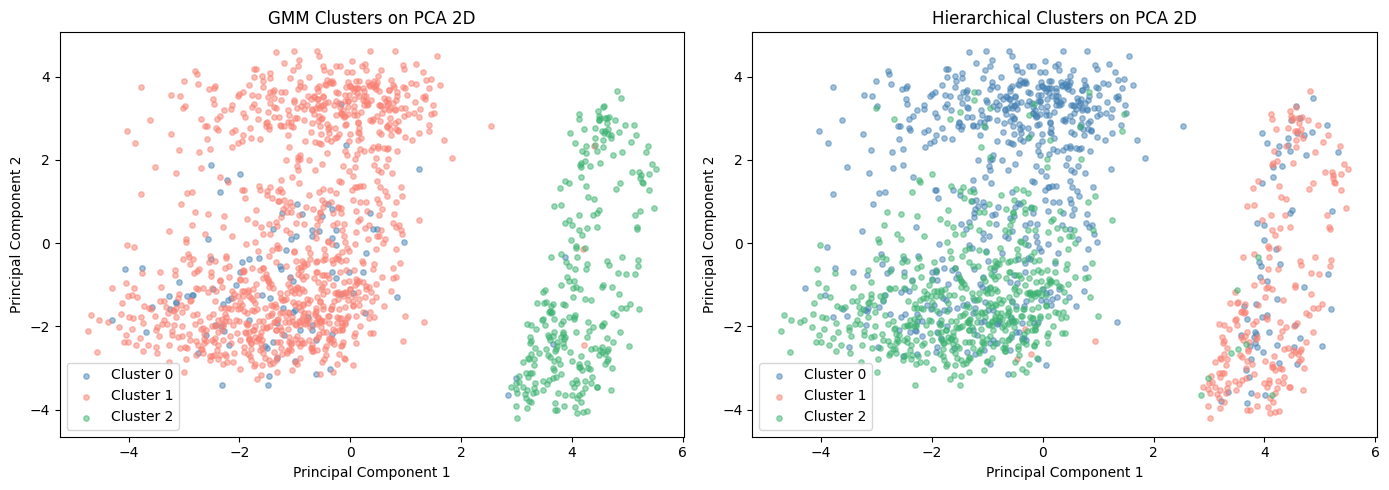

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GMM
for i, color in enumerate(['steelblue', 'salmon', 'mediumseagreen']):
    mask = gmm_labels == i
    axes[0].scatter(df_pca_2[mask, 0], df_pca_2[mask, 1],
                    c=color, label=f'Cluster {i}', alpha=0.5, s=15)
axes[0].set_title('GMM Clusters on PCA 2D')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

# Hierarchical
for i, color in enumerate(['steelblue', 'salmon', 'mediumseagreen']):
    mask = hc_labels == i
    axes[1].scatter(df_pca_2[mask, 0], df_pca_2[mask, 1],
                    c=color, label=f'Cluster {i}', alpha=0.5, s=15)
axes[1].set_title('Hierarchical Clusters on PCA 2D')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('gmm_hierarchical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Clustering**  

K-means with k=3 is selected as the final clustering solution.  
The elbow method did not produce a sharp bend, which is typical for survey data where clusters naturally overlap.   
The silhouette scores are low across all values of k.  

k=3 was chosen over k=2 because the PCA projection already showed three visible groupings, and two clusters would be too coarse to derive meaningful insights.   

GMM achieved a marginally higher silhouette score of 0.1257 compared to K-means at 0.1027, but its cluster distribution was very imbalanced because 73.6% of respondents assigned to a single cluster.  

A clustering solution where one group contains nearly three quarters of the data does not support meaningful interpretation. Hierarchical clustering produced the lowest silhouette score of 0.0629 and showed heavy overlap in the PCA projection.  

K-means produced the most balanced and visually coherent grouping of the three algorithms tested.

## 11. Cluster Profiling and Analysis  

With final K-means solution decided, each cluster is examined in terms of its key characteristics. The original feature values before standardisation are used for profiling to keep the interpretation interpretable. The mean value of selected key features is compared across clusters to identify the defining traits of each group.

In [52]:
df_profile = df.copy()
df_profile['cluster'] = km_labels

print("Cluster sizes:")
print(df_profile['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    683
1    459
2    286
Name: count, dtype: int64


In [53]:
profile_cols = [
    'Are you self-employed?',
    'Do you have a family history of mental illness?',
    'Have you had a mental health disorder in the past?',
    'Do you currently have a mental health disorder?',
    'Have you been diagnosed with a mental health condition by a medical professional?',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?',
    'How willing would you be to share with friends and family that you have a mental illness?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?',
    'age'
]

cluster_profile = df_profile.groupby('cluster')[profile_cols].mean().round(3)
print(cluster_profile.T)

cluster                                                  0       1       2
Are you self-employed?                               0.000   0.000   1.000
Do you have a family history of mental illness?      0.546   0.130   0.344
Have you had a mental health disorder in the past?   0.885   0.149   0.643
Do you currently have a mental health disorder?      0.780   0.096   0.561
Have you been diagnosed with a mental health co...   0.817   0.015   0.521
Do you feel that being identified as a person w...  -0.471  -0.258  -0.392
Do you think that team members/co-workers would...  -0.425  -0.350  -0.323
How willing would you be to share with friends ...   3.603   2.885   3.301
Have you observed or experienced an unsupportiv...  -0.615  -0.390  -0.608
If you have a mental health issue, do you feel ...   2.209   0.298   1.678
If you have a mental health issue, do you feel ...   3.457   0.597   2.490
age                                                 33.578  33.100  36.881


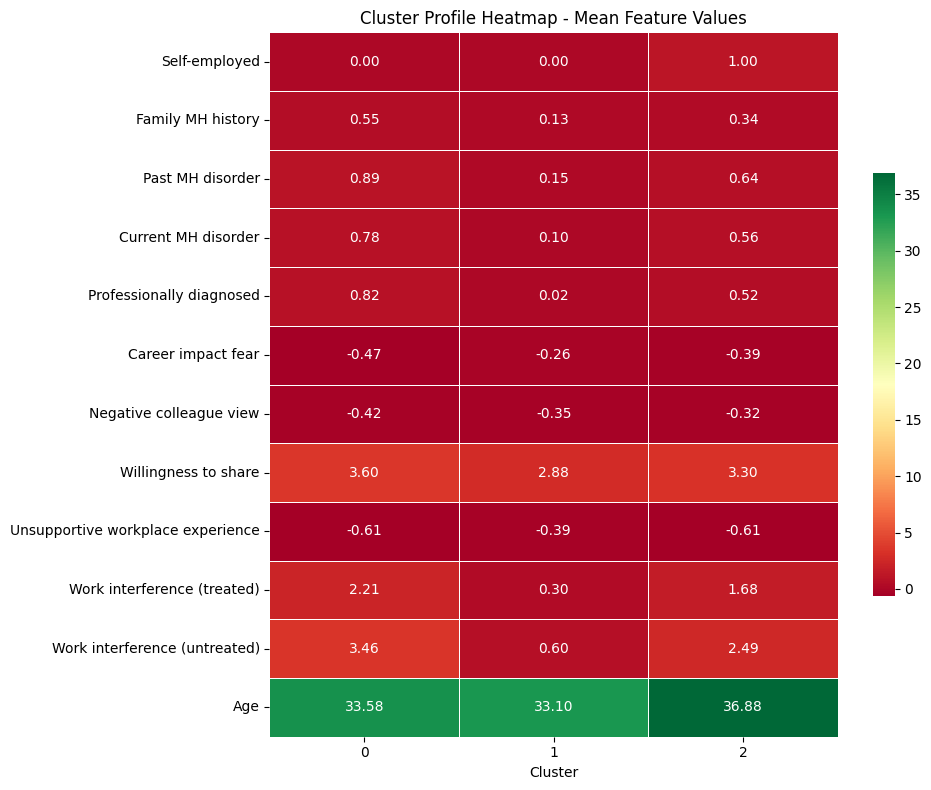

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

# shorten column names for display
short_names = [
    'Self-employed', 'Family MH history', 'Past MH disorder',
    'Current MH disorder', 'Professionally diagnosed',
    'Career impact fear', 'Negative colleague view',
    'Willingness to share', 'Unsupportive workplace experience',
    'Work interference (treated)', 'Work interference (untreated)', 'Age'
]

profile_plot = df_profile.groupby('cluster')[profile_cols].mean()
profile_plot.columns = short_names

sns.heatmap(profile_plot.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title('Cluster Profile Heatmap - Mean Feature Values')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Diagnosis Distribution across Clusters

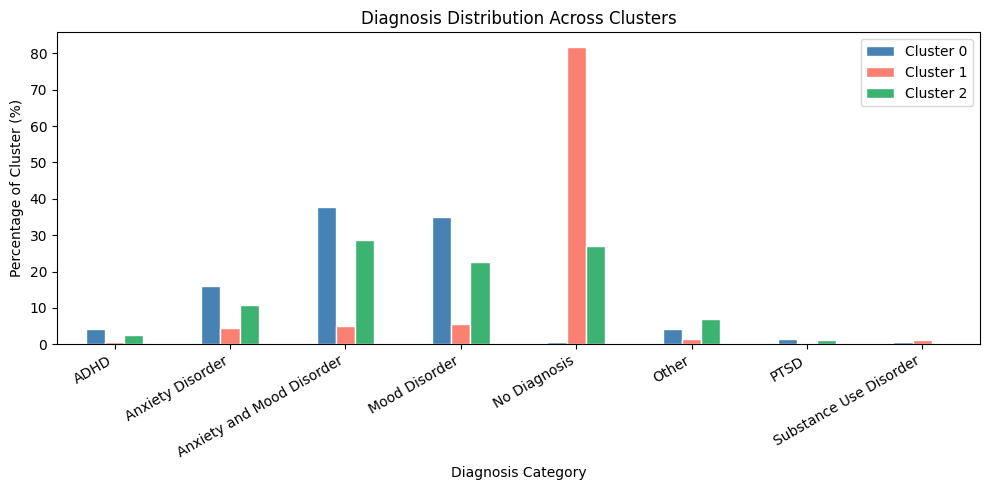

In [55]:
df_original = pd.read_csv('/content/data/mental-heath-in-tech-2016_20161114.csv')

col_yes = [c for c in df_original.columns if 'what condition(s) have you been diagnosed with' in c.lower()][0]
col_maybe = [c for c in df_original.columns if 'what condition(s) do you believe you have' in c.lower()][0]
col_prof = [c for c in df_original.columns if 'what condition(s) were you diagnosed with' in c.lower()][0]

def combine_diagnosis(row):
    for col in [col_prof, col_yes, col_maybe]:
        if pd.notna(row[col]) and str(row[col]).strip() != '':
            return row[col]
    return 'No Diagnosis'

def simplify_diagnosis(val):
    val = str(val)
    if val == 'No Diagnosis':
        return 'No Diagnosis'
    elif 'Mood Disorder' in val and 'Anxiety' in val:
        return 'Anxiety and Mood Disorder'
    elif 'Mood Disorder' in val:
        return 'Mood Disorder'
    elif 'Anxiety Disorder' in val:
        return 'Anxiety Disorder'
    elif 'Attention Deficit' in val:
        return 'ADHD'
    elif 'Post-traumatic' in val:
        return 'PTSD'
    elif 'Substance' in val:
        return 'Substance Use Disorder'
    else:
        return 'Other'

def primary_role(val):
    val = str(val).strip()
    first = val.split('|')[0].strip()
    common_roles = [
        'Back-end Developer', 'Front-end Developer', 'Full-stack Developer',
        'DevOps/SysAdmin', 'Data Scientist', 'Designer', 'Support',
        'Executive Leadership', 'Supervisor/Team Lead', 'One-person shop'
    ]
    for role in common_roles:
        if role.lower() in first.lower():
            return role
    return 'Other'

df_original = df_original[
    (df_original['What is your age?'] >= 18) &
    (df_original['What is your age?'] <= 75)
].reset_index(drop=True)

df_original['combined_diagnosis'] = df_original.apply(combine_diagnosis, axis=1)
df_original['diagnosis_clean'] = df_original['combined_diagnosis'].apply(simplify_diagnosis)
df_original['work_position_clean'] = df_original['Which of the following best describes your work position?'].apply(primary_role)

df_profile['diagnosis_clean'] = df_original['diagnosis_clean'].values
df_profile['work_position_clean'] = df_original['work_position_clean'].values

diag_counts = df_profile.groupby(['cluster', 'diagnosis_clean']).size().unstack(fill_value=0)
diag_pct = diag_counts.div(diag_counts.sum(axis=1), axis=0) * 100

diag_pct.T.plot(kind='bar', figsize=(10, 5),
                color=['steelblue', 'salmon', 'mediumseagreen'],
                edgecolor='white')
plt.xlabel('Diagnosis Category')
plt.ylabel('Percentage of Cluster (%)')
plt.title('Diagnosis Distribution Across Clusters')
plt.xticks(rotation=30, ha='right')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.tight_layout()
plt.savefig('diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

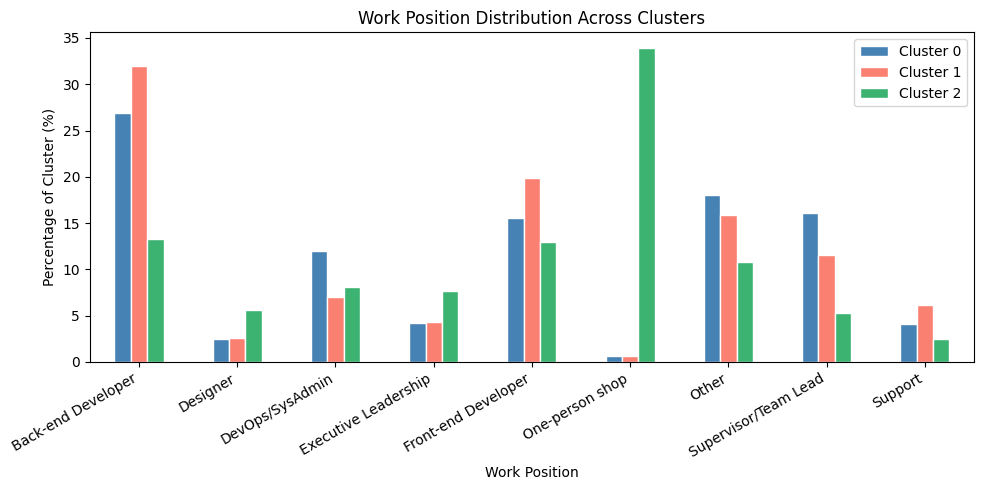

In [56]:
pos_counts = df_profile.groupby(['cluster', 'work_position_clean']).size().unstack(fill_value=0)
pos_pct = pos_counts.div(pos_counts.sum(axis=1), axis=0) * 100

pos_pct.T.plot(kind='bar', figsize=(10, 5),
               color=['steelblue', 'salmon', 'mediumseagreen'],
               edgecolor='white')
plt.xlabel('Work Position')
plt.ylabel('Percentage of Cluster (%)')
plt.title('Work Position Distribution Across Clusters')
plt.xticks(rotation=30, ha='right')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.tight_layout()
plt.savefig('work_position_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

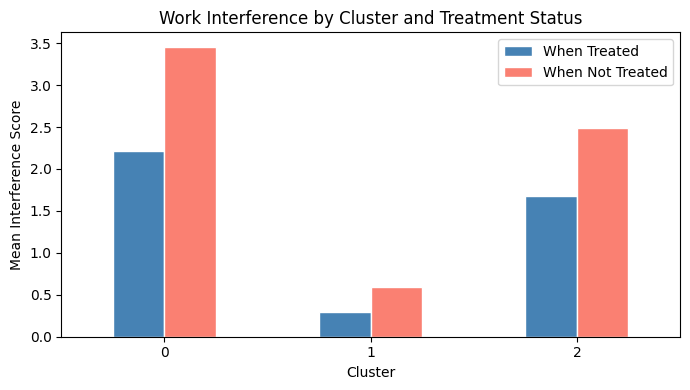

In [57]:
treated_col = 'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'
untreated_col = 'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'

interference_means = df_profile.groupby('cluster')[[treated_col, untreated_col]].mean()
interference_means.columns = ['When Treated', 'When Not Treated']

interference_means.plot(kind='bar', figsize=(7, 4),
                        color=['steelblue', 'salmon'],
                        edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Mean Interference Score')
plt.title('Work Interference by Cluster and Treatment Status')
plt.xticks(rotation=0)
plt.legend(['When Treated', 'When Not Treated'])
plt.tight_layout()
plt.savefig('work_interference.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cluster Analysis and Findings  

The K-means algorithm identified 3 distinct groups within the survey data. The clusters differ primarily along two dimensions - employment type and mental health burden.  

**Cluster 0 - Employed, High Mental Health Burden (683 respondents, 47.7%)**  
All respondents in this cluster are employed. 88.5% report a past mental health disorder, 78% currently have one, and 81.7% have received a professional diagnosis. Anxiety and Mood Disorder combined is the most common diagnosis at 38%, followed by Mood Disorder at 35%. Work inference scores are the highest of all three clusters - 2.21 when treated and 3.46 when not treated. This group has the strongest family history of mental illness (0.55) and the most exposure to unsupportive workplace responses. These respondents represent the most at-risk segment of the workforce.  

**Cluster 1 - Employed, Low Mental Health Burden (459 respondents, 32.1%)**  
This cluster is entirely employed and reports very low rates of mental health conditions. Only 14.9% report a past disorder, 9.6% report a current one, and just 1.5% have a professional diagnosis. Work interference scores are near zero. Over 81% have no diagnosis. This group has the lowest family history (0.13) and the least exposure to unsupportive workplace experiences. They represent the mentally healthy segment of the employed workforce.  

**Cluster 2 - Self-Employed, Moderate Mental Health Burden (286 respondents, 20.0%)**  
All respondents in this cluster are self-employed, with an average age of 36.88 - slightly older than the other groups. Over a third work as one-person shops. 64.3% report a past disorder and 56.1% report a current one. Diagnosis rates are moderate at 52.1%. Work interference is present but lower than Cluster 0. Unlike the employed clusters, these respondents have no access to employer-provided mental health resources, making their situation structurally different rather than purely clinical.
